<a href="https://colab.research.google.com/github/AshrfCode/Anan-Tirgulem/blob/main/lab7_ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn import svm
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
# Plot the data with colored labels and support vectors

def plotData(data, names,labels,kernel,marker,dims=(0,1),supportV = np.empty([0,0])):
    #plot the titles
    plt.title("The Iris Dataset "+ kernel + " SVM grid")
    plt.xlabel(names[dims[0]])
    plt.ylabel(names[dims[1]])

    # plot the centroids if exists in blue and with + marker
    if (supportV.any()):
        plt.scatter(supportV[:,dims[0]], supportV[:,dims[1]], c='black', marker = "+", s=120)
    # plot the data with different color for every label and size of 50 pixels
    myPlot = plt.scatter(data[:,dims[0]],data[:,dims[1]],c = labels, s=50,marker=marker)
    nLabels =len(set(labels))
    plt.legend(handles=myPlot.legend_elements()[0], labels=range(nLabels),loc='upper left')

In [ ]:
# Generate the coordinates grid

def plotGrid(data, labels,kernel,C, dims=(0,1)):
    n_samples, n_features = data.shape
    grid_points=200000
    data = data[:,dims[0]:dims[1]+1]

    # Build 2D synthetic grid sample using bounds of real data
    mins = data.min(axis=0)
    maxs = data.max(axis=0)
    n_features = data.shape[1]
    # Random 2D grid sampling
    grid = np.random.uniform(mins, maxs, size=(grid_points, n_features))

    svmModel= svm.SVC(kernel=kernel,C=C)
    # Predict with the real SVM on full 4D points
    svmModel.fit(data,labels)
    preds = svmModel.predict(grid)

    plt.scatter(grid[:, 0], grid[:, 1],
                c=preds, cmap=plt.cm.coolwarm, s=5)

In [ ]:
Iris = datasets.load_iris()
data = Iris.data
trueLabels = Iris.target # true labeling
featureNames = Iris.feature_names

In [ ]:
#split data to test and train
trainData, testData, trainLabels, testLabels = train_test_split(
    data, trueLabels, test_size = 0.40,stratify=trueLabels)

In [ ]:
kernel='linear'
C=1

# generate a linear SVM model and fit the train data
svmModel= svm.SVC(kernel=kernel,C=C)
svmModel.fit(trainData, trainLabels)

# get and plot the support vectors
supportV = svmModel.support_vectors_
predictedLabels=svmModel.predict(testData)

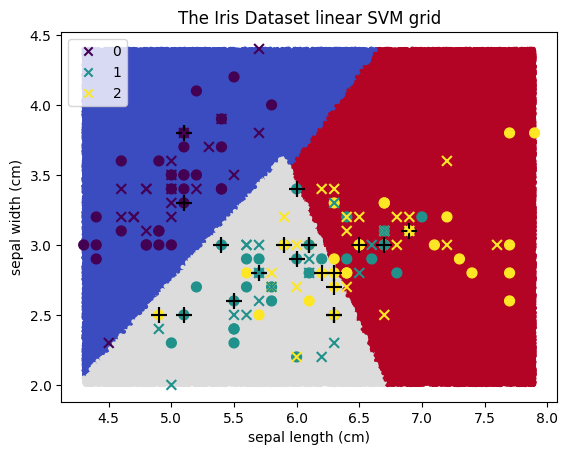

In [ ]:
dims=(0,1)
plotGrid(data,trueLabels,kernel,C,dims)
plotData(trainData, featureNames,trainLabels,kernel,"o",dims,supportV)
plotData(testData, featureNames,predictedLabels,kernel,"x",dims,supportV)
plt.show()

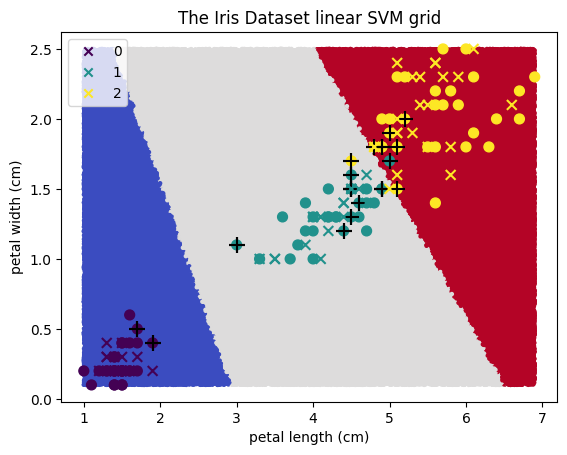

In [ ]:
dims=(2,3)
plotGrid(data,trueLabels,kernel,C,dims)
plotData(trainData, featureNames,trainLabels,kernel,"o",dims,supportV)
plotData(testData, featureNames,predictedLabels,kernel,"x",dims,supportV)
plt.show()

In [ ]:
#Predict using the model
index = 50
sample = testData[index,:]
predictedLabel=svmModel.predict(sample.reshape(1,-1))
print(predictedLabel)

[2]


In [ ]:
fClass = 0
# Get the line parameters
w = svmModel.coef_[fClass]  # w coefficients of 1st function
b = svmModel.intercept_[fClass]  # b coefficient of 1st function

# Equation of the line: w*X + b = 0
np.set_printoptions(precision=2)
print("w=", w)
print("b=%.2f" %b)

w= [ 0.    0.59 -0.97 -0.45]
b=0.90


In [ ]:
# predict using function
# plus is for prediction of the current class
# minus is for prediction of not the current class
f_x = np.dot(w, sample) + b

print ("The true label is",testLabels[index])
if (np.sign(f_x)>=0):
    print ("The predicted label is",fClass)
else:
    print ("The predicted label is not",fClass)

The true label is 2
The predicted label is not 0


# **PART 2**

Run 1
Accuracy: 0.9833333333333333
Number of support vectors: 12


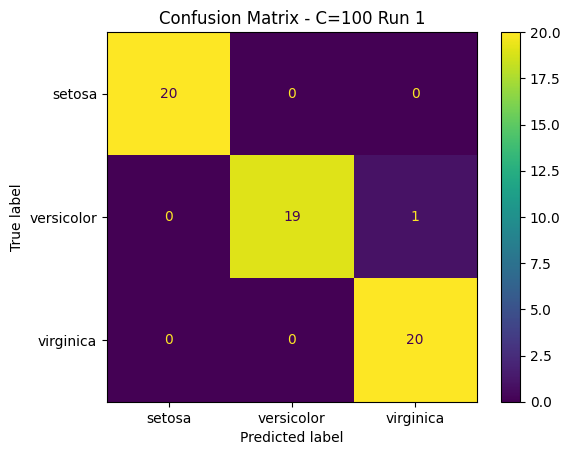

Run 2
Accuracy: 0.9833333333333333
Number of support vectors: 11


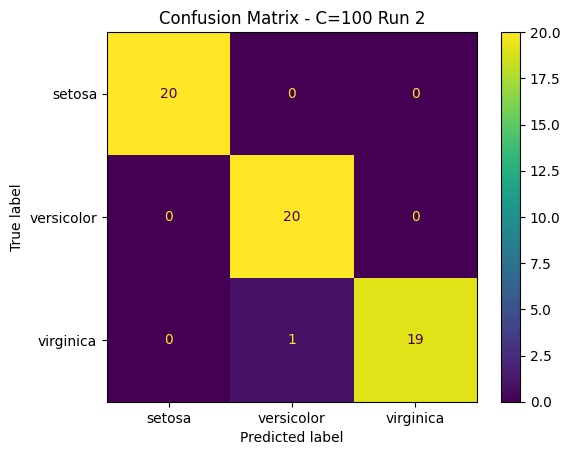

Run 3
Accuracy: 0.9166666666666666
Number of support vectors: 9


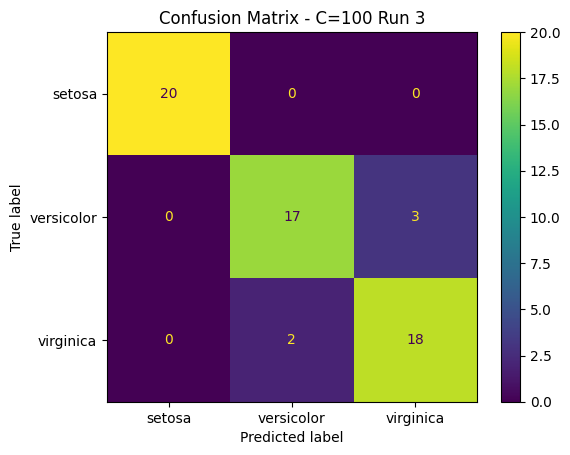

Average accuracy: 0.9611111111111111
Average number of support vectors: 10.666666666666666


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

kernel = 'linear'
C = 100

accuracies = []
support_vectors_counts = []

for run in range(3):

    trainData, testData, trainLabels, testLabels = train_test_split(
        data,
        trueLabels,
        test_size=0.40,
        stratify=trueLabels
    )

    svmModel = svm.SVC(kernel=kernel, C=C)
    svmModel.fit(trainData, trainLabels)

    predictedLabels = svmModel.predict(testData)

    cm = confusion_matrix(testLabels, predictedLabels)
    acc = accuracy_score(testLabels, predictedLabels)

    accuracies.append(acc)

    # number of support vectors in this run
    num_support_vectors = len(svmModel.support_vectors_)
    support_vectors_counts.append(num_support_vectors)

    print("Run", run + 1)

    print("Accuracy:", acc)
    print("Number of support vectors:", num_support_vectors)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=Iris.target_names
    )

    disp.plot()
    plt.title("Confusion Matrix - C=" + str(C) + " Run " + str(run + 1))
    plt.show()

average_accuracy = sum(accuracies) / 3
average_support_vectors = sum(support_vectors_counts) / 3

print("Average accuracy:", average_accuracy)
print("Average number of support vectors:", average_support_vectors)

# **PART 4**

My Manual Predictions:    [0 1 1 1 0 2 0 2 0 1 2 2 2 0 2 0 2 2 0 0 2 0 1 0 1 2 1 2 1 1 0 0 1 1 0 2 1
 1 2 0 2 1 2 1 2 0 2 0 0 1 2 2 2 2 0 1 0 1 1 0]
Scikit-Learn Predictions: [0 1 1 1 0 2 0 2 0 1 2 2 2 0 2 0 2 2 0 0 2 0 1 0 1 2 1 2 1 1 0 0 1 1 0 2 1
 1 2 0 2 1 2 1 2 0 2 0 0 1 2 2 2 2 0 1 0 1 1 0]

Match Rate with Scikit-Learn: 60/60 (100.00%)


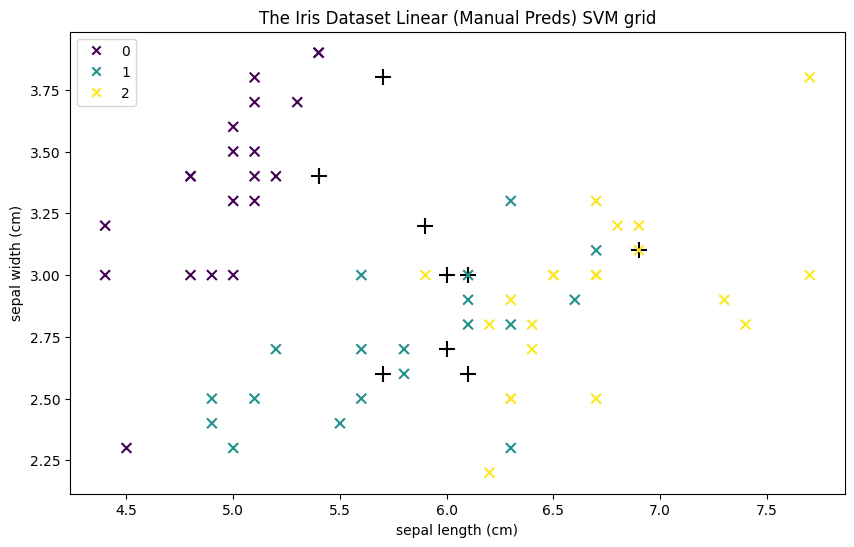

In [ ]:
# 1. Extract the coefficients (weights) and intercepts (bias) from your trained svmModel
W = svmModel.coef_         # Shape: (3, 4) since it's a 3-class One-vs-One model
B = svmModel.intercept_    # Shape: (3,)

# 2. Implement the manual prediction function using the One-vs-One voting strategy
def manual_svm_predict(X, weights, bias):
    # Initialize a voting matrix for the 3 classes (0, 1, 2)
    votes = np.zeros((X.shape[0], 3))

    # Calculate the mathematical decision function values: w * x + b
    # This yields 3 boundary values per sample (one for each pairwise classifier)
    decision_values = np.dot(X, weights.T) + bias

    # Classifier 0: Class 0 vs Class 1
    idx_0 = decision_values[:, 0] > 0
    votes[idx_0, 0] += 1   # Positive value means Class 0 wins
    votes[~idx_0, 1] += 1  # Negative value means Class 1 wins

    # Classifier 1: Class 0 vs Class 2
    idx_1 = decision_values[:, 1] > 0
    votes[idx_1, 0] += 1   # Positive value means Class 0 wins
    votes[~idx_1, 2] += 1  # Negative value means Class 2 wins

    # Classifier 2: Class 1 vs Class 2
    idx_2 = decision_values[:, 2] > 0
    votes[idx_2, 1] += 1   # Positive value means Class 1 wins
    votes[~idx_2, 2] += 1  # Negative value means Class 2 wins

    # The class with the highest number of votes wins!
    return np.argmax(votes, axis=1)

# 3. Predict the test set using your custom manual function
my_predictions = manual_svm_predict(testData, W, B)

# 4. Predict the test set using Scikit-Learn's built-in function
sklearn_predictions = svmModel.predict(testData)

# 5. Compare the results and print them side-by-side
print("My Manual Predictions:   ", my_predictions)
print("Scikit-Learn Predictions:", sklearn_predictions)

# Calculate how many predictions match exactly
matches = np.sum(my_predictions == sklearn_predictions)
total = len(sklearn_predictions)
print(f"\nMatch Rate with Scikit-Learn: {matches}/{total} ({(matches/total)*100:.2f}%)")

# 6. Plot the results using your notebook's built-in plotData function
dims = (0, 1)  # You can change this to (2, 3) to look at the other features!
plt.figure(figsize=(10, 6))

# Plot your manual prediction results
plotData(testData, featureNames, my_predictions, 'Linear (Manual Preds)', 'x', dims, svmModel.support_vectors_)
plt.show()

# **PART 5**

Prediction Accuracy on Overlapping Data: 95.56%

Confusion Matrix (Text Format):
[[28  1  0]
 [ 1 24  1]
 [ 0  1 34]]


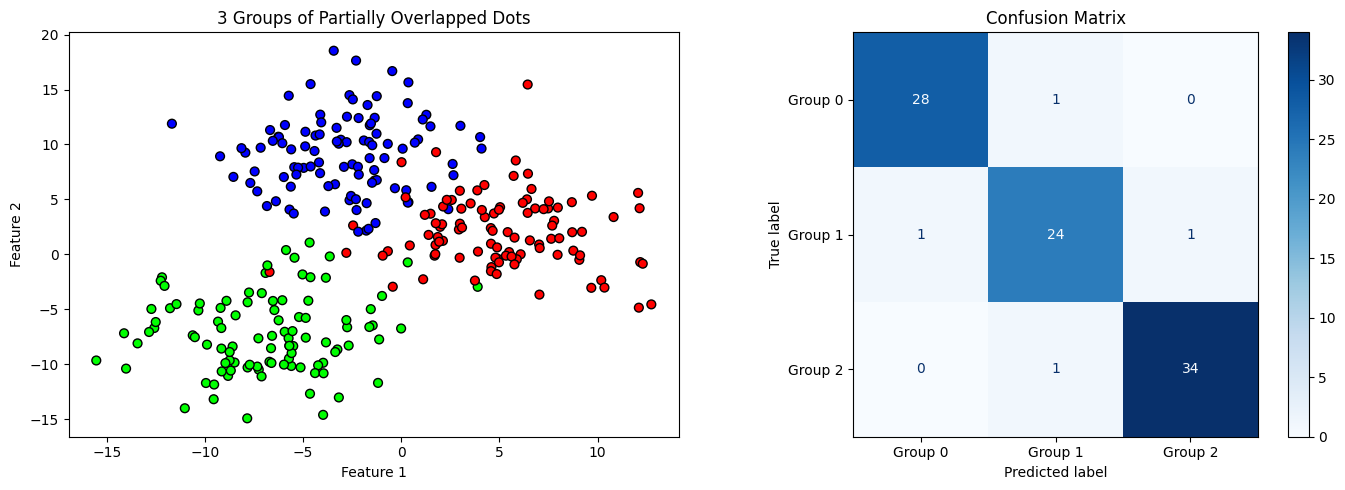

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# 1. Generate random distribution of 3 groups of dots
# n_samples: total number of dots to generate
# centers: number of groups (3)
# cluster_std: How spread out the dots are. A higher number forces them to overlap!
X_random, y_random = make_blobs(n_samples=300, centers=3, n_features=2,
                                cluster_std=3.5, random_state=42)

# 2. Split the generated dots into training and testing sets
X_train_rnd, X_test_rnd, y_train_rnd, y_test_rnd = train_test_split(
    X_random, y_random, test_size=0.3, random_state=42
)

# 3. Train an SVM model to classify the dots
# We are using a Linear kernel
# the SVM to draw curved boundaries through the overlapping areas.
svm_random = svm.SVC(kernel='linear', C=1.0)
svm_random.fit(X_train_rnd, y_train_rnd)

# 4. Classify (predict) the test set
y_pred_rnd = svm_random.predict(X_test_rnd)

# 5. Find the prediction accuracy
accuracy = accuracy_score(y_test_rnd, y_pred_rnd)
print(f"Prediction Accuracy on Overlapping Data: {accuracy * 100:.2f}%\n")

# 6. Compute the confusion matrix
cm = confusion_matrix(y_test_rnd, y_pred_rnd)
print("Confusion Matrix (Text Format):")
print(cm)

# ==========================================
# 7. Plotting the results
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Show the raw overlapping dots
axes[0].scatter(X_random[:, 0], X_random[:, 1], c=y_random, cmap='brg', edgecolors='k', s=40)
axes[0].set_title("3 Groups of Partially Overlapped Dots")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Plot B: Show the Visual Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Group 0", "Group 1", "Group 2"])
disp.plot(ax=axes[1], cmap='Blues')
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()